In [3]:
import shutil
import os

if os.path.exists('/content/drylands_project'):
    shutil.rmtree('/content/drylands_project')
    print("Removed existing 'drylands_project' directory.")
else:
    print("'drylands_project' directory does not exist, nothing to remove.")

!git clone https://github.com/zvireek/drylands_project.git

'drylands_project' directory does not exist, nothing to remove.
Cloning into 'drylands_project'...
remote: Enumerating objects: 111, done.
remote: Counting objects: 100% (111/111), done.
remote: Compressing objects: 100% (85/85), done.
remote: Total 111 (delta 29), reused 96 (delta 18), pack-reused 0 (from 0)
Receiving objects: 100% (111/111), 24.69 KiB | 12.34 MiB/s, done.
Resolving deltas: 100% (29/29), done.


In [4]:
import sys
import numpy as np
import tqdm.auto as tqdm
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

plt.rcParams["animation.html"] = "jshtml"

sys.path.insert(0,'/content/drylands_project')

from pipeline.model import KlausmeierModel
from pipeline.solver import ImplicitSolver

In [5]:
# Defining parameters
dt, steps = 0.1, 1000
dx, L = 0.25, 10 * np.pi
N = int(L/dx) + 1
m = 0.45
d1, d2 = 80, 1

In [ ]:
a_values = np.linspace(0, 3, num=16)

imp_solver = ImplicitSolver()
vs = []

for a in tqdm(a_values):
  klaus_model = KlausmeierModel(dx, L, a, m, d1, d2)
  u_end, v_end = klaus_model.run_simulation(dt, steps, imp_solver, tolerance = 0, verbose=False)
  vs.append(v_end.reshape(N, N))

  0%|          | 0/16 [00:00<?, ?it/s]

Model initial conditions set to: something
Solver parameters set up with LU decomposition.
Model initial conditions set to: something
Solver parameters set up with LU decomposition.
Model initial conditions set to: something
Solver parameters set up with LU decomposition.
Model initial conditions set to: something
Solver parameters set up with LU decomposition.
Model initial conditions set to: something
Solver parameters set up with LU decomposition.
Model initial conditions set to: something
Solver parameters set up with LU decomposition.
Model initial conditions set to: something
Solver parameters set up with LU decomposition.
Model initial conditions set to: something
Solver parameters set up with LU decomposition.
Model initial conditions set to: something
Solver parameters set up with LU decomposition.
Model initial conditions set to: something
Solver parameters set up with LU decomposition.
Model initial conditions set to: something
Solver parameters set up with LU decomposition.

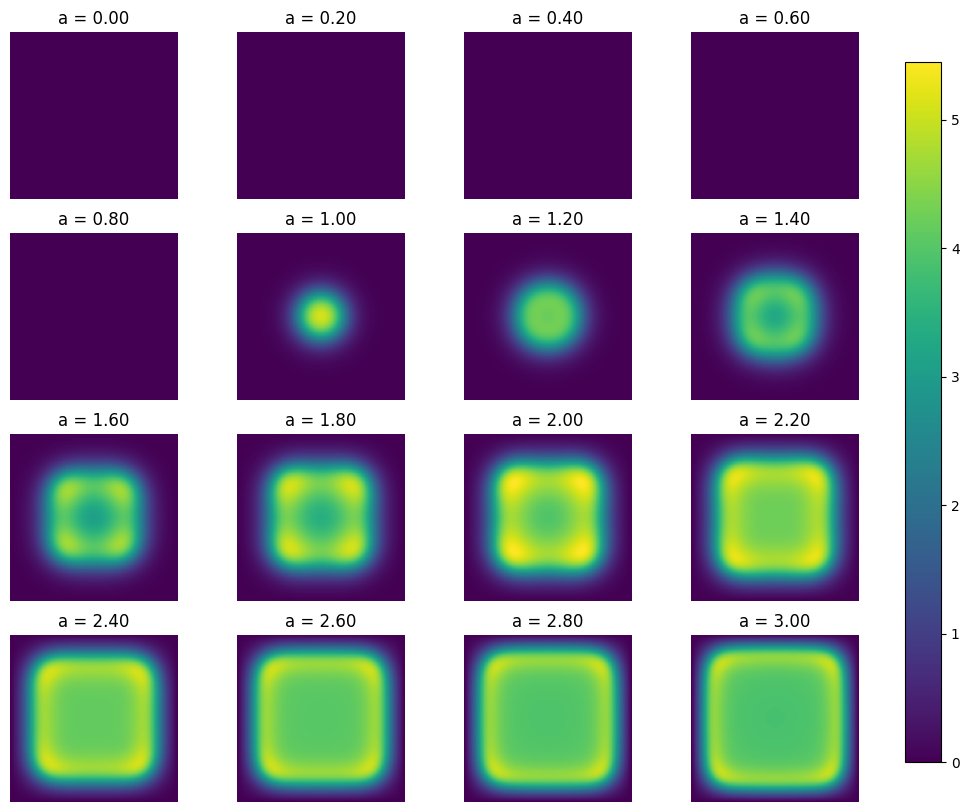

In [ ]:
fig, axes = plt.subplots(4, 4, figsize=(12, 10))
axes = axes.flatten()

vmin = 0
vmax = np.max(vs)

for i in range(len(vs)):
    im = axes[i].imshow(vs[i], vmin=vmin, vmax=vmax, cmap='viridis')
    axes[i].set_title(f'a = {a_values[i]:.2f}')
    axes[i].axis('off')
    axes[i].set_aspect('equal')

fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.88, 0.15, 0.03, 0.7])
fig.colorbar(im, cax=cbar_ax)

plt.show()

In [19]:
# Defining parameters
dt, steps = 0.1, 1000
dx, L = 0.25, 100
N = int(L/dx) + 1
m = 0.45
d1, d2 = 2, 0.01

In [20]:
a_values = np.linspace(0, 1.7, num=16)

imp_solver = ImplicitSolver()
vs = []

for a in tqdm(a_values):
  klaus_model = KlausmeierModel(dx, L, a, m, d1, d2)
  u_end, v_end = klaus_model.run_simulation(dt, steps, imp_solver, tolerance = 0, verbose=False)
  vs.append(v_end.reshape(N, N))

  0%|          | 0/16 [00:00<?, ?it/s]

Model initial conditions set to: something
Solver parameters set up with LU decomposition.
Model initial conditions set to: something
Solver parameters set up with LU decomposition.
Model initial conditions set to: something
Solver parameters set up with LU decomposition.
Model initial conditions set to: something
Solver parameters set up with LU decomposition.
Model initial conditions set to: something
Solver parameters set up with LU decomposition.
Model initial conditions set to: something
Solver parameters set up with LU decomposition.
Model initial conditions set to: something
Solver parameters set up with LU decomposition.
Model initial conditions set to: something
Solver parameters set up with LU decomposition.


/content/drylands_project/pipeline/solver.py:68: RuntimeWarning:

overflow encountered in multiply

/content/drylands_project/pipeline/solver.py:69: RuntimeWarning:

overflow encountered in multiply



Model initial conditions set to: something
Solver parameters set up with LU decomposition.
Model initial conditions set to: something
Solver parameters set up with LU decomposition.
Model initial conditions set to: something
Solver parameters set up with LU decomposition.
Model initial conditions set to: something
Solver parameters set up with LU decomposition.
Model initial conditions set to: something
Solver parameters set up with LU decomposition.
Model initial conditions set to: something
Solver parameters set up with LU decomposition.
Model initial conditions set to: something
Solver parameters set up with LU decomposition.
Model initial conditions set to: something
Solver parameters set up with LU decomposition.


In [ ]:
import os
import numpy as np

output_dir = 'simulation_results'
os.makedirs(output_dir, exist_ok=True)

for i, (v_array, a_val) in enumerate(zip(vs, a_values)):
    filename = os.path.join(output_dir, f'simulation_a_{a_val:.2f}.csv')
    np.savetxt(filename, v_array, delimiter=',')

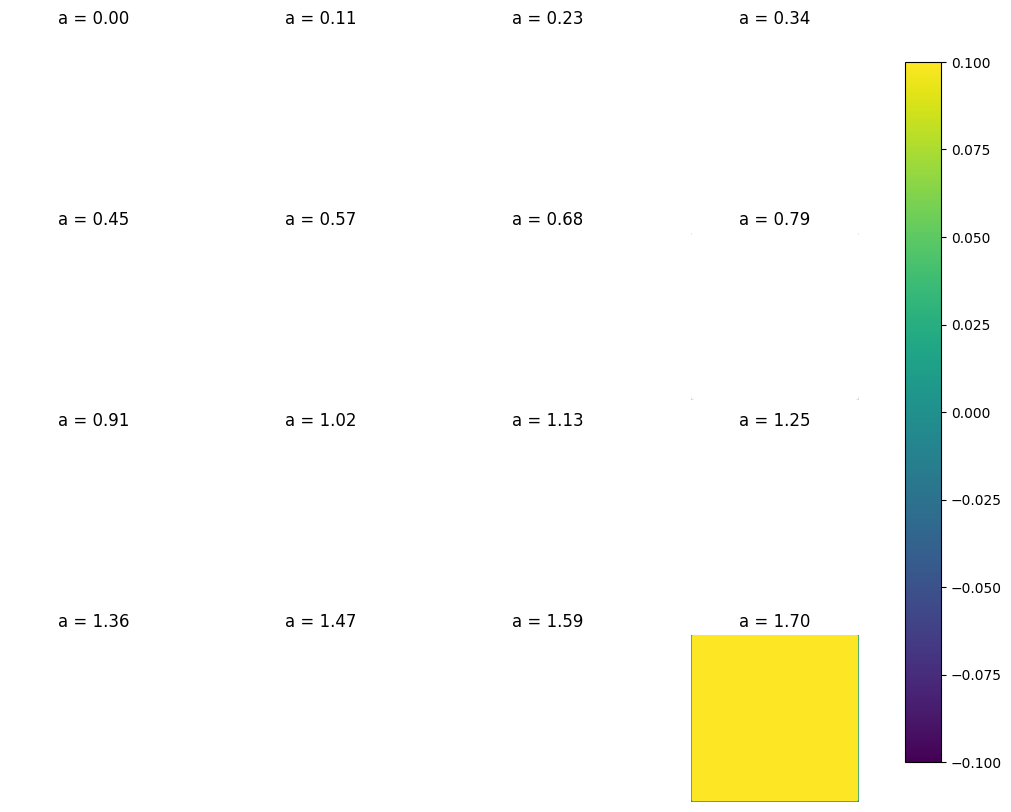

In [23]:
fig, axes = plt.subplots(4, 4, figsize=(12, 10))
axes = axes.flatten()

vmin = 0
vmax = np.max(vs)

for i in range(len(vs)):
    im = axes[i].imshow(vs[i], vmin=vmin, vmax=vmax, cmap='viridis')
    axes[i].set_title(f'a = {a_values[i]:.2f}')
    axes[i].axis('off')
    axes[i].set_aspect('equal')

fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.88, 0.15, 0.03, 0.7])
fig.colorbar(im, cax=cbar_ax)

plt.show()